# 🔍 DBSCAN & Density-Based Clustering - Complete Learning Guide

## Overview
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) clusters data by grouping points that are closely packed together. Unlike K-Means, it can find clusters of arbitrary shapes and automatically identify outliers as noise points.

## Key Topics Covered:
1. **Density-Based Clustering** - Core vs border vs noise points
2. **DBSCAN Algorithm** - eps and min_samples parameters
3. **Parameter Tuning** - Finding optimal eps and min_samples
4. **Non-spherical Clusters** - Handling irregular shapes
5. **Outlier Detection** - Automatic noise point identification
6. **Scalability** - Performance on large datasets
7. **Distance Metrics** - Different distance measures
8. **Advantages & Disadvantages** - When to use DBSCAN

---

## References:
- [DBSCAN - Wikipedia](https://en.wikipedia.org/wiki/DBSCAN)
- [scikit-learn DBSCAN](https://scikit-learn.org/stable/modules/clustering.html#dbscan)
- [DBSCAN Tutorial](https://www.youtube.com/watch?v=C3r7UJrja00)

## 📚 Section 1: Import Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🔍 Section 2: DBSCAN Basics


🔍 EXAMPLE 1: Basic DBSCAN Clustering

✅ DBSCAN Results:
  eps = 0.5, min_samples = 5
  Number of clusters: 3
  Number of noise points: 10
  Cluster distribution: [98 97 95]


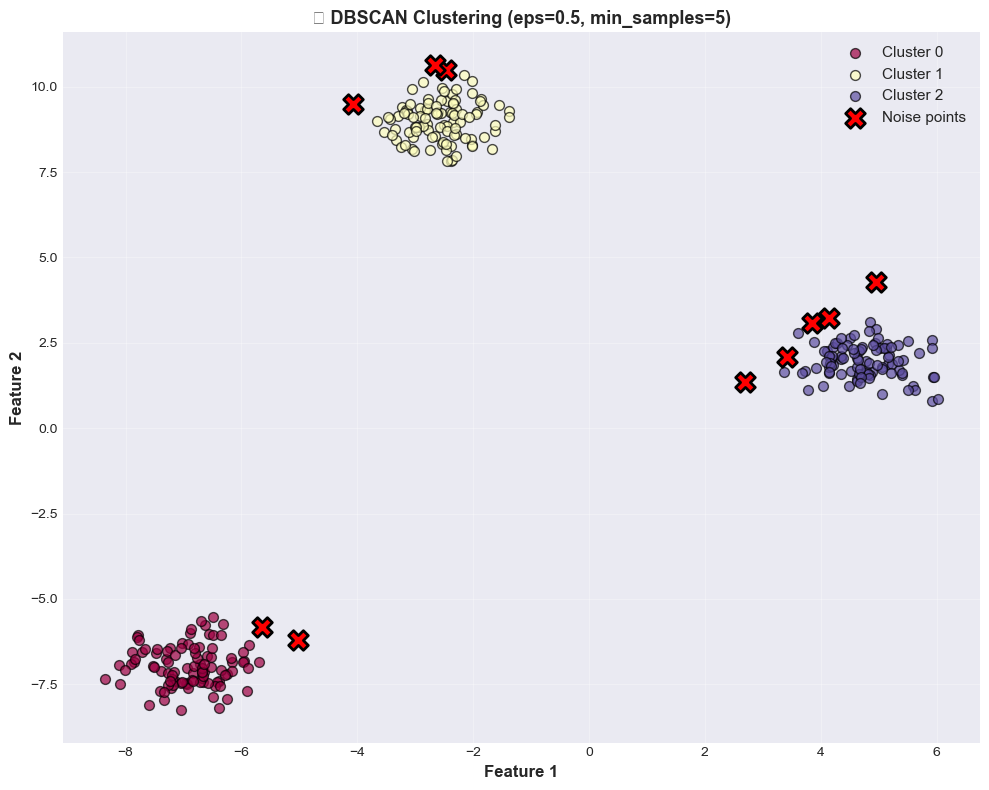

In [2]:
# Example 1: Basic DBSCAN
print("\n" + "="*70)
print("🔍 EXAMPLE 1: Basic DBSCAN Clustering")
print("="*70)

# Create synthetic data with well-separated clusters
X_blobs, y_true = make_blobs(n_samples=300, centers=3, n_features=2, 
                              cluster_std=0.6, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_blobs)

# Count clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n✅ DBSCAN Results:")
print(f"  eps = 0.5, min_samples = 5")
print(f"  Number of clusters: {n_clusters}")
print(f"  Number of noise points: {n_noise}")
print(f"  Cluster distribution: {np.bincount(labels[labels >= 0])}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Plot clusters
colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))
for i in range(n_clusters):
    mask = labels == i
    ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=[colors[i]], 
              label=f'Cluster {i}', s=50, alpha=0.7, edgecolors='k')

# Plot noise points
mask_noise = labels == -1
if n_noise > 0:
    ax.scatter(X_blobs[mask_noise, 0], X_blobs[mask_noise, 1], 
              c='red', marker='X', s=200, label='Noise points', edgecolors='k', linewidth=2)

ax.set_xlabel('Feature 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2', fontsize=12, fontweight='bold')
ax.set_title('🔍 DBSCAN Clustering (eps=0.5, min_samples=5)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Section 3: Parameter Tuning - eps & min_samples


📊 EXAMPLE 2: Parameter Tuning - eps and min_samples

🔍 Testing different parameter combinations:
  min_samples=3:
    eps=0.3: 7 clusters, 32 noise points
    eps=0.5: 3 clusters, 5 noise points
    eps=0.8: 3 clusters, 1 noise points
    eps=1.0: 3 clusters, 1 noise points
    eps=0.3: 5 clusters, 52 noise points
    eps=0.5: 3 clusters, 10 noise points
    eps=0.8: 3 clusters, 1 noise points
    eps=1.0: 3 clusters, 1 noise points
    eps=0.3: 3 clusters, 131 noise points
    eps=0.5: 3 clusters, 24 noise points
    eps=0.8: 3 clusters, 2 noise points
    eps=1.0: 3 clusters, 1 noise points


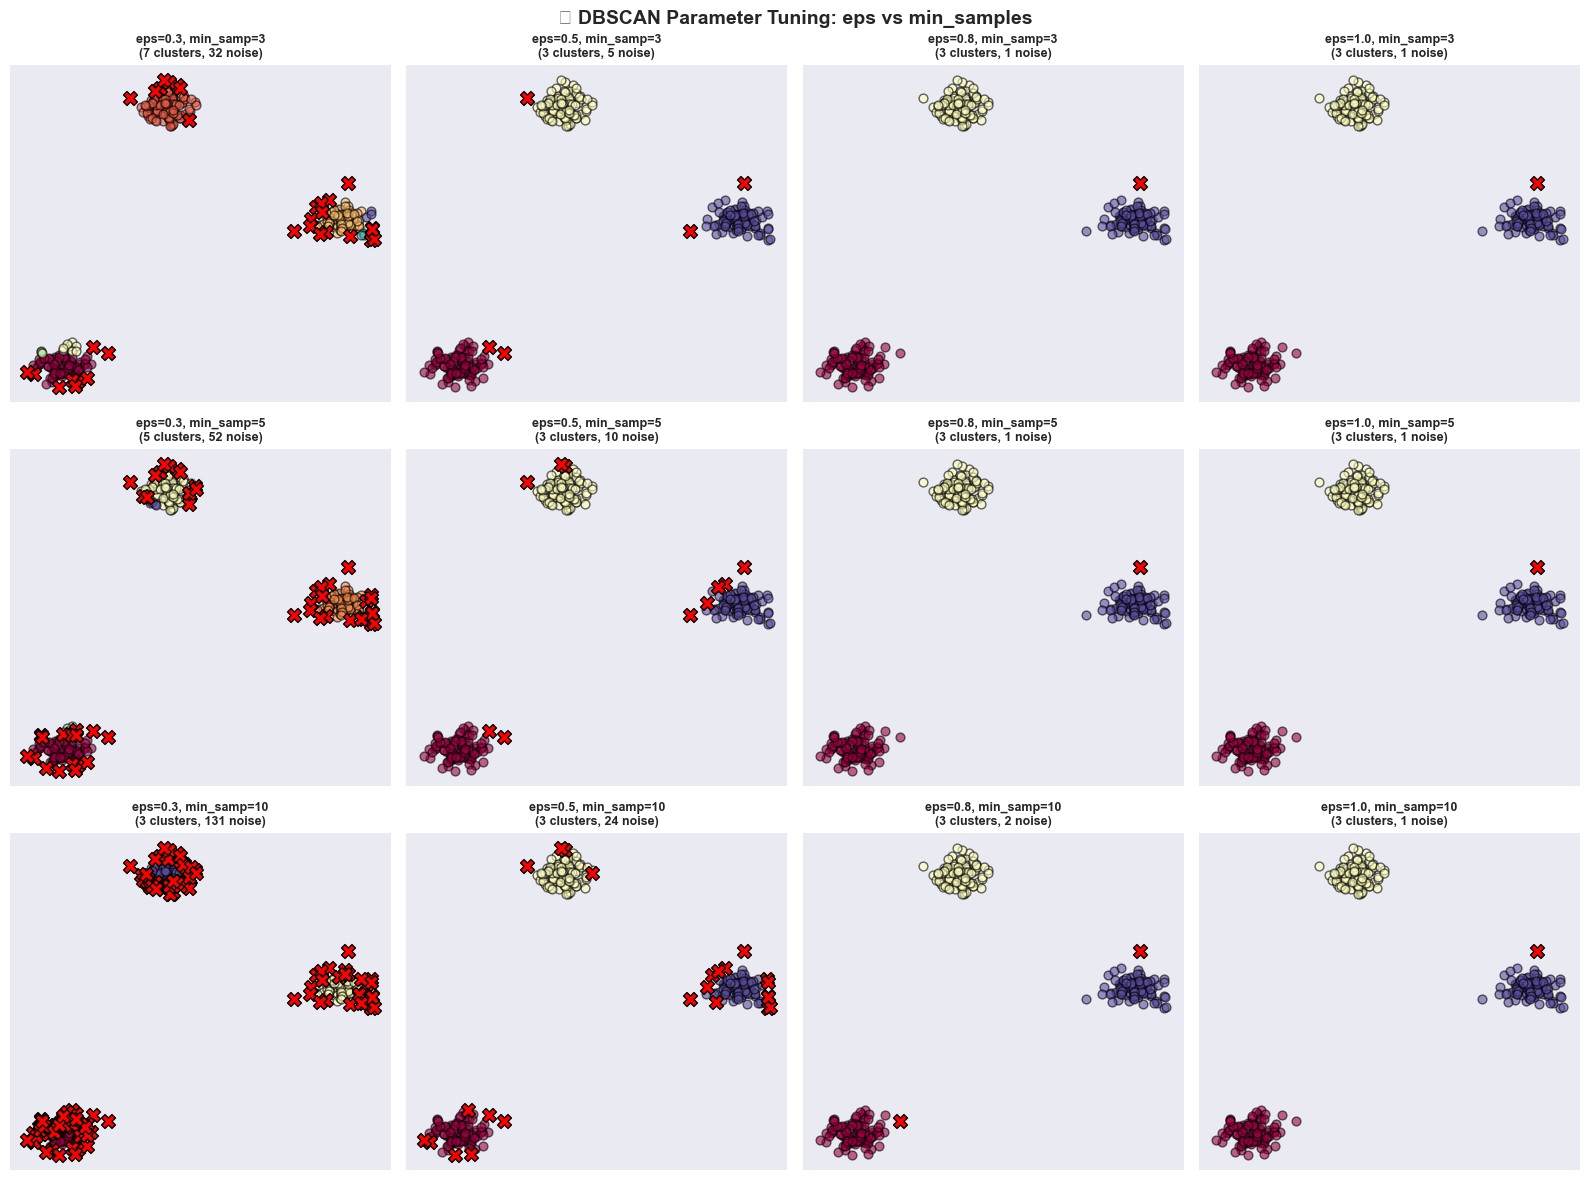

In [3]:
# Example 2: DBSCAN Parameter Tuning
print("\n" + "="*70)
print("📊 EXAMPLE 2: Parameter Tuning - eps and min_samples")
print("="*70)

eps_values = [0.3, 0.5, 0.8, 1.0]
min_samples_values = [3, 5, 10]

fig, axes = plt.subplots(len(min_samples_values), len(eps_values), figsize=(16, 12))
fig.suptitle('📊 DBSCAN Parameter Tuning: eps vs min_samples', fontsize=14, fontweight='bold')

print(f"\n🔍 Testing different parameter combinations:")
for i, min_samp in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        ax = axes[i, j]
        
        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samp)
        labels_temp = dbscan_temp.fit_predict(X_blobs)
        
        n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise_temp = list(labels_temp).count(-1)
        
        if i == 0 and j == 0:
            print(f"  min_samples={min_samp}:")
        print(f"    eps={eps}: {n_clusters_temp} clusters, {n_noise_temp} noise points")
        
        # Plot
        colors = plt.cm.Spectral(np.linspace(0, 1, max(n_clusters_temp, 1)))
        for k in range(n_clusters_temp):
            mask = labels_temp == k
            ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=[colors[k]], 
                      s=40, alpha=0.6, edgecolors='k')
        
        if n_noise_temp > 0:
            mask_noise = labels_temp == -1
            ax.scatter(X_blobs[mask_noise, 0], X_blobs[mask_noise, 1], 
                      c='red', marker='X', s=100, edgecolors='k')
        
        ax.set_title(f'eps={eps}, min_samp={min_samp}\n({n_clusters_temp} clusters, {n_noise_temp} noise)', 
                    fontsize=9, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 🎯 Section 4: Non-Spherical Clusters


🎯 EXAMPLE 3: DBSCAN on Non-Spherical Data

✅ DBSCAN on Moon Dataset:
  eps = 0.2, min_samples = 5
  Number of clusters: 7
  Number of noise points: 25


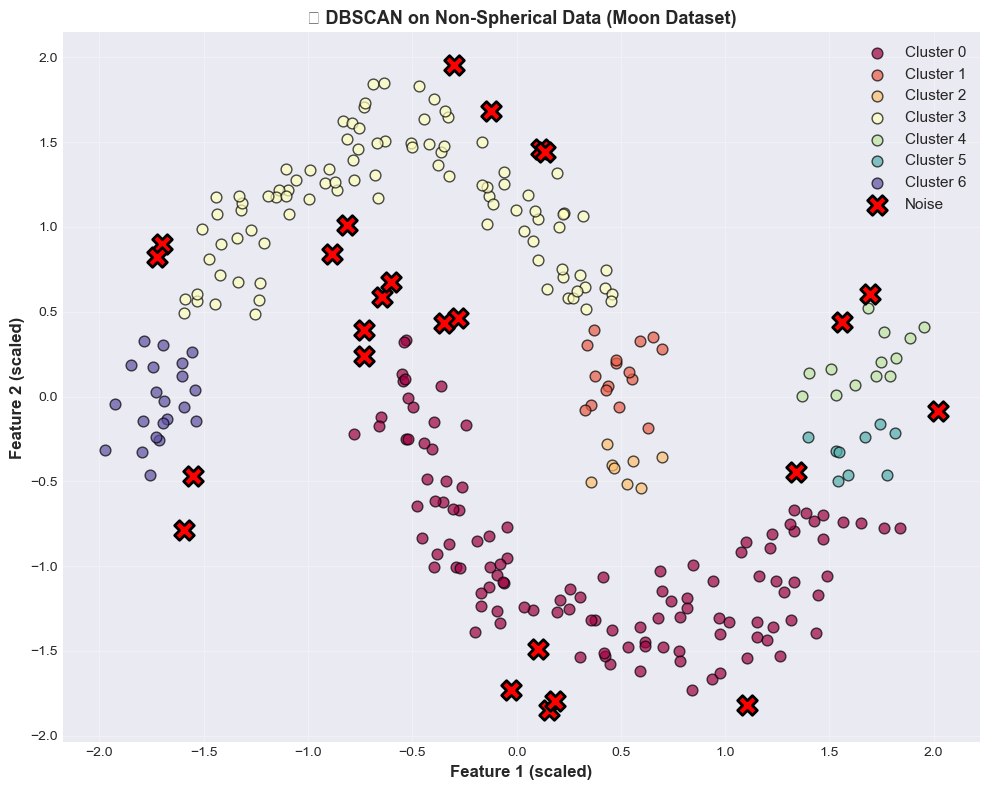


✅ DBSCAN advantage: Captures non-spherical cluster shapes!


In [4]:
# Example 3: DBSCAN on Non-Spherical Data
print("\n" + "="*70)
print("🎯 EXAMPLE 3: DBSCAN on Non-Spherical Data")
print("="*70)

# Create moon-shaped dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

# Scale
scaler = StandardScaler()
X_moons_scaled = scaler.fit_transform(X_moons)

# DBSCAN
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_moons = dbscan_moons.fit_predict(X_moons_scaled)

n_clusters_moons = len(set(labels_moons)) - (1 if -1 in labels_moons else 0)
n_noise_moons = list(labels_moons).count(-1)

print(f"\n✅ DBSCAN on Moon Dataset:")
print(f"  eps = 0.2, min_samples = 5")
print(f"  Number of clusters: {n_clusters_moons}")
print(f"  Number of noise points: {n_noise_moons}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters_moons))
for i in range(n_clusters_moons):
    mask = labels_moons == i
    ax.scatter(X_moons_scaled[mask, 0], X_moons_scaled[mask, 1], 
              c=[colors[i]], label=f'Cluster {i}', s=60, alpha=0.7, edgecolors='k')

if n_noise_moons > 0:
    mask_noise = labels_moons == -1
    ax.scatter(X_moons_scaled[mask_noise, 0], X_moons_scaled[mask_noise, 1], 
              c='red', marker='X', s=200, label='Noise', edgecolors='k', linewidth=2)

ax.set_xlabel('Feature 1 (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2 (scaled)', fontsize=12, fontweight='bold')
ax.set_title('🎯 DBSCAN on Non-Spherical Data (Moon Dataset)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ DBSCAN advantage: Captures non-spherical cluster shapes!")

## 🔬 Section 5: eps Selection - k-distance Graph


🔬 EXAMPLE 4: k-distance Graph for eps Selection

✅ k-distance Analysis (k=5):
  Min distance: 0.0867
  Max distance: 1.4317
  Mean distance: 0.2796
  Recommended eps region: 0.3219 - 0.5963


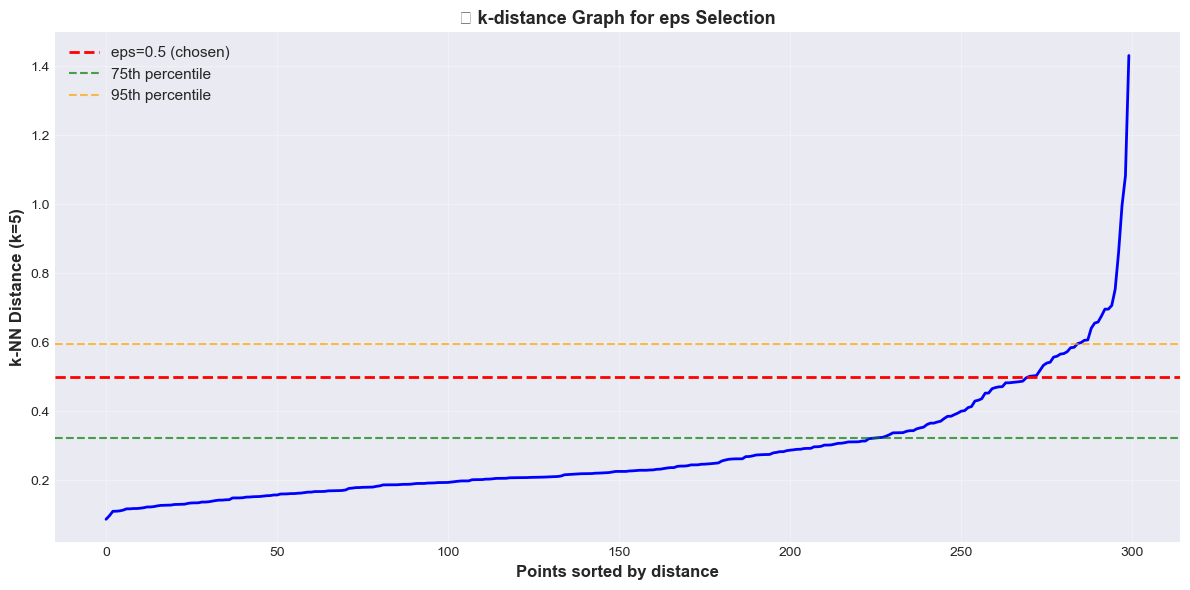


✅ eps Selection Strategy:
  1. Plot k-distance graph (k=min_samples)
  2. Look for 'elbow' point where distance jumps
  3. Choose eps at the elbow
  4. This represents transition from core to noise


In [5]:
# Example 4: k-distance Graph for eps Selection
print("\n" + "="*70)
print("🔬 EXAMPLE 4: k-distance Graph for eps Selection")
print("="*70)

# Calculate k-distances
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_blobs)
distances, indices = neighbors_fit.kneighbors(X_blobs)

# Sort distances
distances = np.sort(distances[:, k-1], axis=0)

print(f"\n✅ k-distance Analysis (k={k}):")
print(f"  Min distance: {distances.min():.4f}")
print(f"  Max distance: {distances.max():.4f}")
print(f"  Mean distance: {distances.mean():.4f}")
print(f"  Recommended eps region: {np.percentile(distances, 75):.4f} - {np.percentile(distances, 95):.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(distances, linewidth=2, color='blue')
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='eps=0.5 (chosen)')
ax.axhline(y=np.percentile(distances, 75), color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='75th percentile')
ax.axhline(y=np.percentile(distances, 95), color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='95th percentile')

ax.set_xlabel('Points sorted by distance', fontsize=12, fontweight='bold')
ax.set_ylabel('k-NN Distance (k=5)', fontsize=12, fontweight='bold')
ax.set_title('🔬 k-distance Graph for eps Selection', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ eps Selection Strategy:")
print(f"  1. Plot k-distance graph (k=min_samples)")
print(f"  2. Look for 'elbow' point where distance jumps")
print(f"  3. Choose eps at the elbow")
print(f"  4. This represents transition from core to noise")

## 📈 Section 6: DBSCAN on Real Dataset


📈 EXAMPLE 5: DBSCAN on Iris Dataset

✅ DBSCAN on Iris Dataset:
  eps = 0.3, min_samples = 5
  Number of clusters: 2
  Number of noise points: 40
  Cluster distribution:
    Cluster 0: 36 points
    Cluster 1: 74 points
    Noise: 40 points


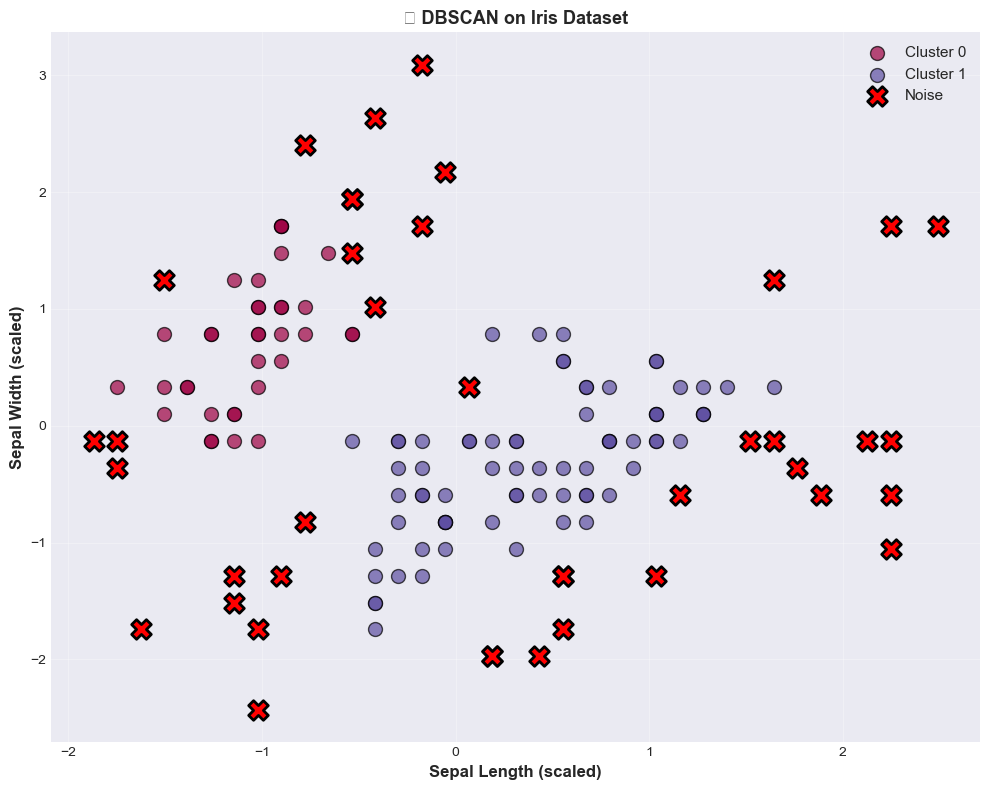

In [6]:
# Example 5: DBSCAN on Iris Dataset
print("\n" + "="*70)
print("📈 EXAMPLE 5: DBSCAN on Iris Dataset")
print("="*70)

# Load Iris
iris = load_iris()
X_iris = iris.data[:, :2]  # Use first 2 features for visualization

# Scale
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# DBSCAN
dbscan_iris = DBSCAN(eps=0.3, min_samples=5)
labels_iris = dbscan_iris.fit_predict(X_iris_scaled)

n_clusters_iris = len(set(labels_iris)) - (1 if -1 in labels_iris else 0)
n_noise_iris = list(labels_iris).count(-1)

print(f"\n✅ DBSCAN on Iris Dataset:")
print(f"  eps = 0.3, min_samples = 5")
print(f"  Number of clusters: {n_clusters_iris}")
print(f"  Number of noise points: {n_noise_iris}")
print(f"  Cluster distribution:")
for i in range(n_clusters_iris):
    print(f"    Cluster {i}: {np.sum(labels_iris == i)} points")
print(f"    Noise: {n_noise_iris} points")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters_iris))
for i in range(n_clusters_iris):
    mask = labels_iris == i
    ax.scatter(X_iris_scaled[mask, 0], X_iris_scaled[mask, 1], 
              c=[colors[i]], label=f'Cluster {i}', s=100, alpha=0.7, edgecolors='k')

if n_noise_iris > 0:
    mask_noise = labels_iris == -1
    ax.scatter(X_iris_scaled[mask_noise, 0], X_iris_scaled[mask_noise, 1], 
              c='red', marker='X', s=200, label='Noise', edgecolors='k', linewidth=2)

ax.set_xlabel('Sepal Length (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sepal Width (scaled)', fontsize=12, fontweight='bold')
ax.set_title('📈 DBSCAN on Iris Dataset', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 Section 7: DBSCAN - Advantages & Disadvantages

### ✅ Advantages:
1. **Arbitrary shapes** - Finds non-spherical clusters
2. **No k required** - No need to specify number of clusters
3. **Automatic outlier detection** - Identifies noise points
4. **Deterministic** - Same result every time
5. **Interpretable** - Core points, border points, noise clear
6. **Works with any distance metric** - Flexible distance measures

### ❌ Disadvantages:
1. **Parameter selection** - Need to choose eps and min_samples
2. **Varying cluster density** - Fails with varying-density clusters
3. **High-dimensional data** - Distance becomes less meaningful (curse of dimensionality)
4. **Computational cost** - O(n²) in worst case for eps calculation
5. **Scalability** - Not ideal for very large datasets
6. **Sensitive to parameters** - Small changes in eps dramatically affect results

### When to Use:
- Non-spherical cluster shapes
- Unknown number of clusters
- Outlier detection needed
- Small to medium datasets
- When k-means fails on your data
- Anomaly/noise detection

In [7]:
# Example 6: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "DBSCAN: Density-Based Spatial Clustering of Applications with Noise",
    "Core concept: Groups points that are densely packed together",
    "Three point types: core (≥min_samples neighbors), border, noise",
    "Parameters: eps (radius) and min_samples (min points in eps-neighborhood)",
    "Advantage: Can find arbitrary-shaped clusters (unlike K-Means)",
    "Automatic outlier detection: Points marked as noise (-1 label)",
    "eps selection: Use k-distance graph, look for elbow point",
    "Always scale features before DBSCAN (distance metrics important!)",
    "Small eps → many noise points, large eps → few clusters",
    "Fails with varying-density clusters (HDBSCAN better for that)",
    "Not ideal for high-dimensional data (curse of dimensionality)",
    "Great for outlier detection and noise identification!"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. DBSCAN: Density-Based Spatial Clustering of Applications with Noise

 2. Core concept: Groups points that are densely packed together

 3. Three point types: core (≥min_samples neighbors), border, noise

 4. Parameters: eps (radius) and min_samples (min points in eps-neighborhood)

 5. Advantage: Can find arbitrary-shaped clusters (unlike K-Means)

 6. Automatic outlier detection: Points marked as noise (-1 label)

 7. eps selection: Use k-distance graph, look for elbow point

 8. Always scale features before DBSCAN (distance metrics important!)

 9. Small eps → many noise points, large eps → few clusters

10. Fails with varying-density clusters (HDBSCAN better for that)

11. Not ideal for high-dimensional data (curse of dimensionality)

12. Great for outlier detection and noise identification!

